# 🌴 CPO Short-Term Daily Price Forecasting Pipeline
**Model: Super Hybrid Ensemble + Intervention Analysis (Rational Transfer Function)**

---

## 📁 File Input yang Dibutuhkan

| Variabel Konfigurasi | File | Format |
|---|---|---|
| `SUPPLY_FILE` | Data USDA PSD (output Cell 1 atau manual) | CSV dengan kolom `Category`, `Country`, `YYYY/YY` |
| `FASTMARKETS_FILE` | Export Fastmarkets `.csv` | 4 baris header, lalu `M/D/YYYY,Price` |
| `FX_FILE` | Data kurs SAP | CSV kolom `DATE_SAP`, `KURST`, `TCURR`, `FCURR`, `FINAL_UKURS` |

## 🔄 Alur Eksekusi

```
Cell 1  →  Cell 2  →  Cell 3  →  Cell 4  →  Cell 5  →  Cell 6  →  Cell 7
(USDA)   (Preproc)   (EDA)    (Ensemble) (Intervensi) (Kalibrasi) (Export)
```

> **Catatan Penting:**
> - Cell 1 bisa dilewati jika `SUPPLY_FILE` sudah tersedia secara lokal.
> - Data harga murni dari **Fastmarkets** — tidak ada file real price eksternal / validasi.
> - FX: hanya MYR & CNY dari SAP. **INR tidak digunakan.**
> - ω & δ dikalibrasi untuk satuan **HARI** (bukan bulan).


---
## Cell 1 — USDA PSD Download & Table Builder
**Output:** `SUPPLY_FILE` (CSV) siap pakai di Cell 2. Jalankan sekali saja.


In [1]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 1 — USDA PSD DOWNLOAD & TABLE BUILDER                     ║
╚══════════════════════════════════════════════════════════════════╝
"""
import pandas as pd
import numpy as np
import requests, zipfile, io, os

# ── ⚙️  KONFIGURASI ────────────────────────────────────────────────────────────
URL_ZIP          = "https://apps.fas.usda.gov/psdonline/downloads/psd_oilseeds_csv.zip"
CSV_NAME         = "psd_oilseeds.csv"
COMMODITY_TARGET = "Oil, Palm"
START_YEAR       = 1964
END_YEAR         = 2026
OUTPUT_CSV       = "1964-2026.csv"  # ← sesuaikan SUPPLY_FILE di Cell 2

CONFIG_TABLE_11 = {
    'Production'          : ['Indonesia','Malaysia','Thailand','Colombia','Nigeria'],
    'Imports'             : ['India','China','European Union','Pakistan','United States',
                             'Bangladesh','Egypt','Vietnam','Philippines','Kenya'],
    'Exports'             : ['Indonesia','Malaysia','Thailand','Papua New Guinea','Guatemala'],
    'Domestic Consumption': ['Indonesia','India','Malaysia','China','Pakistan',
                             'European Union','Thailand','Nigeria','United States',
                             'Bangladesh','Colombia','Egypt','Philippines','Vietnam','Brazil'],
    'Ending Stocks'       : ['Indonesia','Malaysia','India','Colombia','China']
}
# ──────────────────────────────────────────────────────────────────────────────

print("1. Mengunduh data terbaru dari USDA PSD...")
try:
    r = requests.get(URL_ZIP, timeout=60); r.raise_for_status()
    zipfile.ZipFile(io.BytesIO(r.content)).extractall(".")
    print("   ✅ Download & ekstrak berhasil.")
except Exception as e:
    print(f"   ⚠️  Gagal download — coba file lokal. Error: {e}")
    if not os.path.exists(CSV_NAME):
        raise FileNotFoundError(f"File lokal '{CSV_NAME}' tidak ditemukan.")

df = pd.read_csv(CSV_NAME)
df.columns = df.columns.str.replace('_','').str.replace(' ','').str.lower()
df = df.rename(columns={'commoditydescription':'Commodity','countryname':'Country',
                         'marketyear':'Year','attributedescription':'Attribute','value':'Value'})
df_palm = df[(df['Commodity']==COMMODITY_TARGET)&(df['Year']>=START_YEAR)&(df['Year']<=END_YEAR)].copy()

years_range = range(START_YEAR, END_YEAR+1)
year_labels = [f"{y}/{str(y+1)[-2:]}" for y in years_range]
all_rows = []

for category, specific_countries in CONFIG_TABLE_11.items():
    cat_df = df_palm[df_palm['Attribute']==category]
    pivot  = cat_df.pivot_table(index='Country',columns='Year',values='Value',aggfunc='sum',fill_value=0)
    for y in years_range:
        if y not in pivot.columns: pivot[y] = 0.0
    pivot = pivot[sorted(pivot.columns)]
    for country in specific_countries + ['Other','Total']:
        if country == 'Total':       row_vals = pivot.sum().values
        elif country == 'Other':
            others = [c for c in pivot.index if c not in specific_countries]
            row_vals = pivot.loc[others].sum().values if others else np.zeros(len(years_range))
        else: row_vals = pivot.loc[country].values if country in pivot.index else np.zeros(len(years_range))
        row_dict = {'Category': category, 'Country': country}
        for i, label in enumerate(year_labels): row_dict[label] = round(row_vals[i], 2)
        all_rows.append(row_dict)

final_df = pd.DataFrame(all_rows)
# final_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ SELESAI — {OUTPUT_CSV}  ({len(final_df)} baris, {year_labels[0]} → {year_labels[-1]})")
print(f"👉 Pastikan SUPPLY_FILE di Cell 2 mengarah ke: '{OUTPUT_CSV}'")


1. Mengunduh data terbaru dari USDA PSD...
   ✅ Download & ekstrak berhasil.

✅ SELESAI — 1964-2026.csv  (50 baris, 1964/65 → 2026/27)
👉 Pastikan SUPPLY_FILE di Cell 2 mengarah ke: '1964-2026.csv'


---
## Cell 2 — Data Loading & Preprocessing (Daily)
**Input:** `SUPPLY_FILE`, `FASTMARKETS_FILE`, `FX_FILE`

**Output (globals):** `supply_daily`, `supply_monthly`, `prices_daily`, `prices_monthly`, `fx_daily`, `fx_monthly`, `latest_kurs`, `last_actual_price`

> ℹ️ Supply USDA (tahunan) diinterpolasi → bulanan → **harian** untuk eksogen model.
> INR **tidak** dimuat. Harga murni dari Fastmarkets.


In [1]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 2 — DATA LOADING & PREPROCESSING (DAILY)                   ║
╚══════════════════════════════════════════════════════════════════╝
"""
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── ⚙️  KONFIGURASI ────────────────────────────────────────────────────────────
SUPPLY_FILE            = "1964-2026_apr.csv"
FASTMARKETS_FILE       = "Fastmarkets_CPO_Malaysia.csv"
FX_FILE                = "exchange_rate.csv"
PRIMARY_SYM            = "AG-PLM-0008"

FORECAST_HORIZON_DAYS    = 250
OUTLIER_ZSCORE_THRESHOLD = 3.5
FX_CLIP_MYR              = (2.5, 5.5)
FX_CLIP_CNY              = (5.0, 9.0)
# ──────────────────────────────────────────────────────────────────────────────

# ─── [1/3] SUPPLY & DEMAND (USDA PSD → Tahunan → Bulanan → Harian) ───────────
print(">>> [1/3] Loading Supply & Demand (USDA PSD)...")

df_sup    = pd.read_csv(SUPPLY_FILE)
year_cols = [c for c in df_sup.columns if '/' in c]
years     = [int(c.split('/')[0])+1 for c in year_cols]
df_sup    = df_sup.rename(columns=dict(zip(year_cols, years)))

def get_total(category, df):
    if category == 'Ending Stocks':
        return df[(df['Category']==category)&(df['Country']!='Total')][years].sum(axis=0)
    row = df[(df['Category']==category)&(df['Country']=='Total')][years]
    return row.iloc[0] if len(row)>0 else pd.Series(0, index=years)

supply = pd.DataFrame({
    'prod'  : get_total('Production',           df_sup),
    'imp'   : get_total('Imports',              df_sup),
    'exp'   : get_total('Exports',              df_sup),
    'cons'  : get_total('Domestic Consumption', df_sup),
    'stocks': get_total('Ending Stocks',        df_sup)
})
supply['beginning_stock'] = supply['stocks'].shift(1)
supply['total_supply']    = supply['beginning_stock'] + supply['prod'] + supply['imp']
supply['total_demand']    = supply['exp'] + supply['cons']
supply['stu']             = (supply['stocks'] / supply['total_demand'] * 100).replace([np.inf,-np.inf], np.nan)

supply.index   = pd.to_datetime(supply.index.astype(str), format='%Y') + pd.offsets.YearEnd(0)
supply_monthly = supply.resample('ME').interpolate('time')

end_dt_sup    = pd.to_datetime('2026-05-31')
daily_sup_idx = pd.date_range(start=supply_monthly.index[0], end=end_dt_sup, freq='D')
supply_daily  = supply_monthly.reindex(daily_sup_idx).interpolate(method='time').ffill().bfill()

print(f"    Supply monthly : {supply_monthly.index[0].date()} → {supply_monthly.index[-1].date()}")
print(f"    Supply daily   : {supply_daily.index[0].date()} → {supply_daily.index[-1].date()}")

# ─── [2/3] FX DATA (MYR + CNY — tanpa INR) ───────────────────────────────────
print(">>> [2/3] Loading FX Data (SAP — MYR & CNY only, NO INR)...")

df_fx = pd.read_csv(FX_FILE)
df_fx['DATE_SAP'] = pd.to_datetime(df_fx['DATE_SAP'], errors='coerce')
df_fx = df_fx[df_fx['KURST']=='M'].sort_values('DATE_SAP')

usd_myr_raw = (df_fx[(df_fx['TCURR']=='USD')&(df_fx['FCURR']=='MYR')]
               .drop_duplicates('DATE_SAP',keep='last').set_index('DATE_SAP')['FINAL_UKURS'])
usd_myr_raw = 1 / usd_myr_raw

usd_cny_raw = (df_fx[(df_fx['TCURR']=='USD')&(df_fx['FCURR']=='CNY')]
               .drop_duplicates('DATE_SAP',keep='last').set_index('DATE_SAP')['FINAL_UKURS'])

start_dt  = min(df_fx['DATE_SAP'].min(), supply_monthly.index.min())
end_dt    = pd.to_datetime('2027-12-31')
daily_idx = pd.date_range(start=start_dt, end=end_dt, freq='D')

fx_daily = pd.DataFrame(index=daily_idx)
fx_daily['USD_MYR'] = usd_myr_raw.reindex(daily_idx).interpolate(method='linear',limit=7).ffill().bfill()
fx_daily['USD_CNY'] = usd_cny_raw.reindex(daily_idx).interpolate(method='linear',limit=7).ffill().bfill()
fx_daily['USD_MYR'] = fx_daily['USD_MYR'].clip(*FX_CLIP_MYR)
fx_daily['USD_CNY'] = fx_daily['USD_CNY'].clip(*FX_CLIP_CNY)
fx_monthly = fx_daily.resample('ME').mean()

latest_kurs = fx_monthly['USD_MYR'].dropna().iloc[-1]
print(f"    USD/MYR terkini: {latest_kurs:.4f}")

# ─── [3/3] PRICE DATA (FASTMARKETS — Native MYR, NO FX conversion) ───────────
print(">>> [3/3] Loading Fastmarkets Price Data (native MYR/MT)...")

df_price_fm = pd.read_csv(FASTMARKETS_FILE, skiprows=4, header=None, names=['assessment_date','price'])
df_price_fm = df_price_fm[pd.to_datetime(df_price_fm['assessment_date'],errors='coerce').notna()].copy()
df_price_fm['assessment_date'] = pd.to_datetime(df_price_fm['assessment_date'],format='%m/%d/%Y',errors='coerce')
df_price_fm['price'] = pd.to_numeric(df_price_fm['price'].astype(str).str.replace(',',''), errors='coerce')
df_price_fm['symbol'] = PRIMARY_SYM
df_price_fm = df_price_fm.dropna(subset=['assessment_date','price']).sort_values('assessment_date')

prices_daily, prices_monthly = {}, {}

for sym in df_price_fm['symbol'].unique():
    df_sym = (df_price_fm[df_price_fm['symbol']==sym]
              .drop_duplicates('assessment_date',keep='last')
              .set_index('assessment_date')['price'])

    # Rolling z-score outlier removal
    roll_mean    = df_sym.rolling(30,min_periods=5,center=True).mean()
    roll_std     = df_sym.rolling(30,min_periods=5,center=True).std()
    z_score      = (df_sym - roll_mean) / roll_std
    df_sym_clean = df_sym.copy()
    df_sym_clean[z_score.abs() > OUTLIER_ZSCORE_THRESHOLD] = np.nan
    df_sym_clean = df_sym_clean.interpolate(method='time').ffill().bfill()

    # Daily: isi semua hari (termasuk hari non-assessment via interpolasi)
    full_daily_idx  = pd.date_range(start=df_sym_clean.index.min(),
                                    end=df_sym_clean.index.max(), freq='D')
    # ✅ Harga Fastmarkets sudah MYR/MT — tidak perlu konversi FX
    price_daily_ser = df_sym_clean.reindex(full_daily_idx).interpolate(method='time').ffill().bfill()

    prices_daily[sym] = pd.DataFrame({'price_myr': price_daily_ser})

    # Monthly aggregate
    m_price = prices_daily[sym]['price_myr'].resample('ME').mean().to_frame(name='price_myr')
    m_price['pct_price']  = m_price['price_myr'].pct_change() * 100
    m_price['log_price']  = np.log(m_price['price_myr'].clip(lower=1))
    m_price['dlog_price'] = m_price['log_price'].diff()
    prices_monthly[sym]   = m_price

last_actual_price = prices_daily[PRIMARY_SYM]['price_myr'].dropna().iloc[-1]

print(f"\n{'='*60}")
print(f"✅ PREPROCESSING SELESAI (DAILY MODE — Harga Native MYR)")
print(f"{'='*60}")
print(f"  Fastmarkets  : {df_price_fm['assessment_date'].min().date()} → {df_price_fm['assessment_date'].max().date()}")
print(f"  Harga (MYR)  : RM {last_actual_price:.0f}/MT")
print(f"  USD/MYR ref  : {latest_kurs:.2f}  (dipakai untuk variabel FX lain)")
print(f"  Supply daily : {supply_daily.index[0].date()} → {supply_daily.index[-1].date()}")
print(f"\n  Variabel siap: supply_daily, supply_monthly, prices_daily,")
print(f"                 prices_monthly, fx_daily, fx_monthly,")
print(f"                 latest_kurs, last_actual_price")

>>> [1/3] Loading Supply & Demand (USDA PSD)...
    Supply monthly : 1965-12-31 → 2026-12-31
    Supply daily   : 1965-12-31 → 2026-05-31
>>> [2/3] Loading FX Data (SAP — MYR & CNY only, NO INR)...
    USD/MYR terkini: 3.9569
>>> [3/3] Loading Fastmarkets Price Data (native MYR/MT)...

✅ PREPROCESSING SELESAI (DAILY MODE — Harga Native MYR)
  Fastmarkets  : 2017-03-02 → 2026-04-14
  Harga (MYR)  : RM 4465/MT
  USD/MYR ref  : 3.96  (dipakai untuk variabel FX lain)
  Supply daily : 1965-12-31 → 2026-05-31

  Variabel siap: supply_daily, supply_monthly, prices_daily,
                 prices_monthly, fx_daily, fx_monthly,
                 latest_kurs, last_actual_price


---
## Cell 3 — Exploratory Data Analysis (EDA)
**Input:** `prices_daily`, `prices_monthly`, `supply_monthly`, `fx_monthly`


>>> Memulai EDA (Daily Mode)...


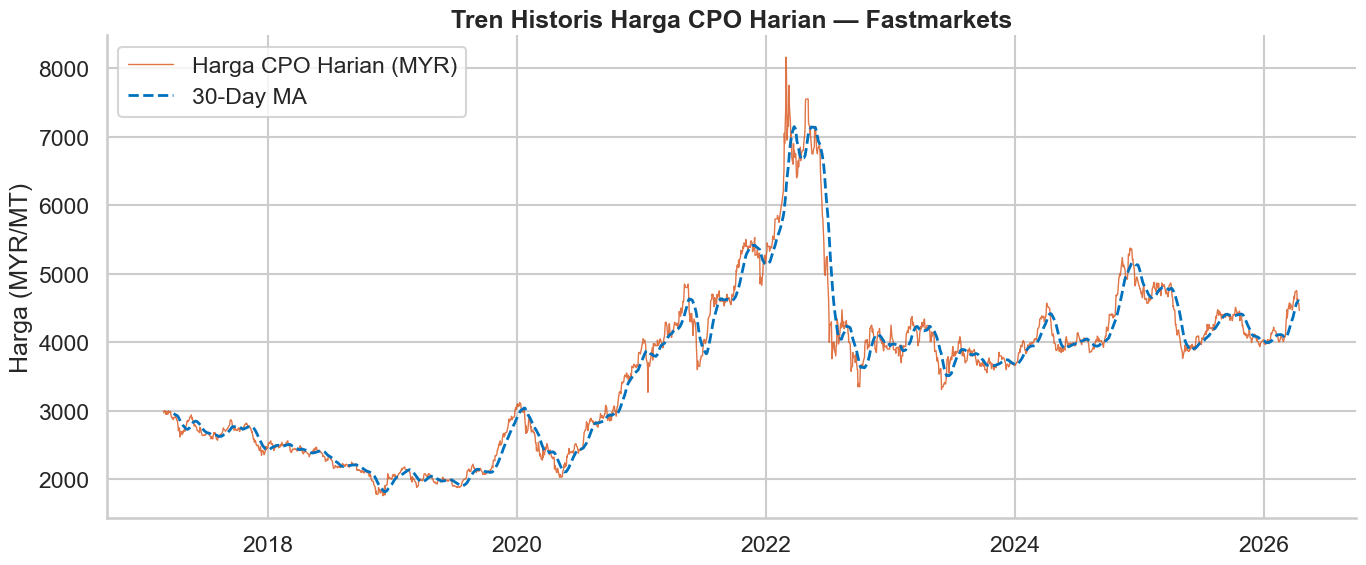

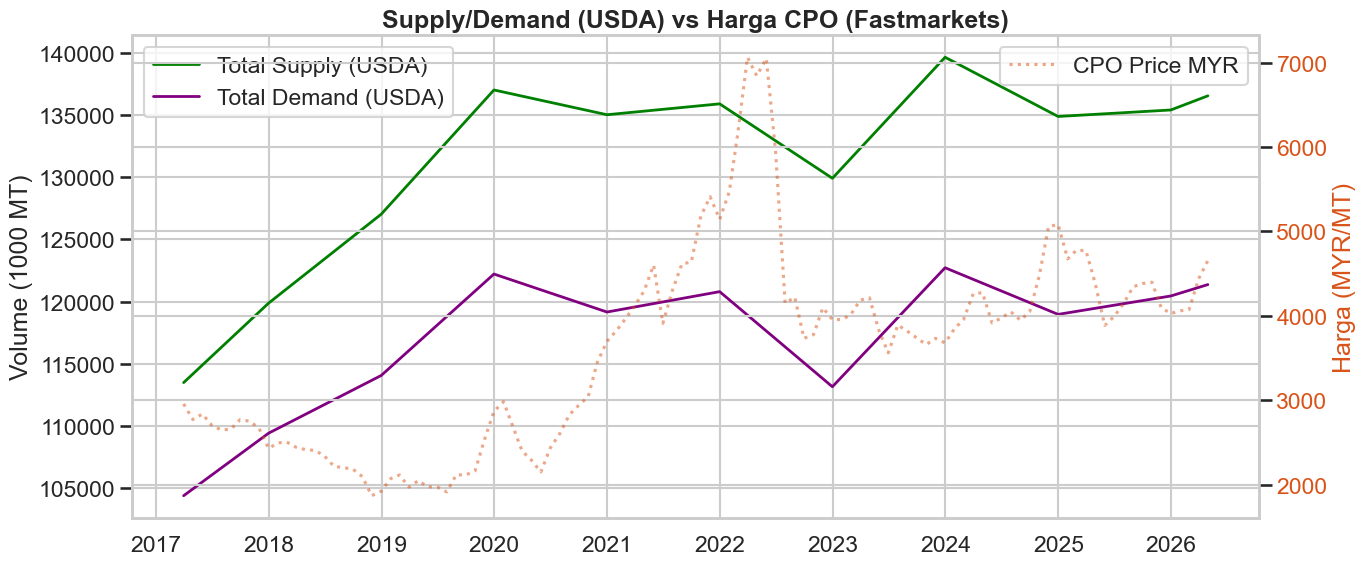

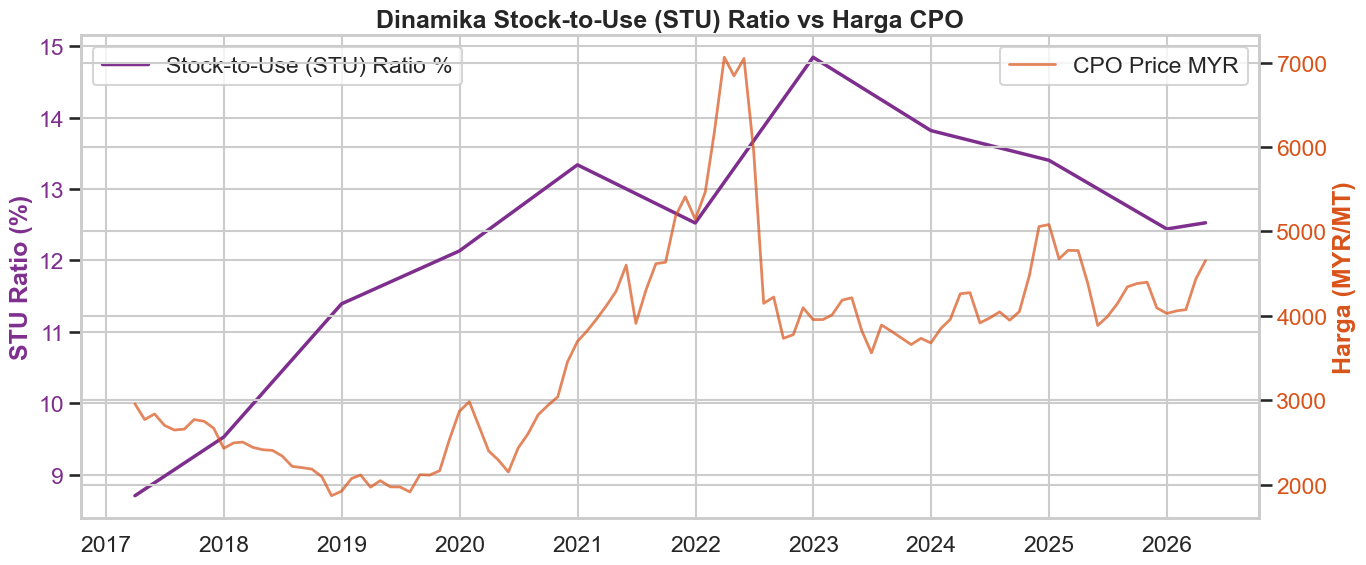

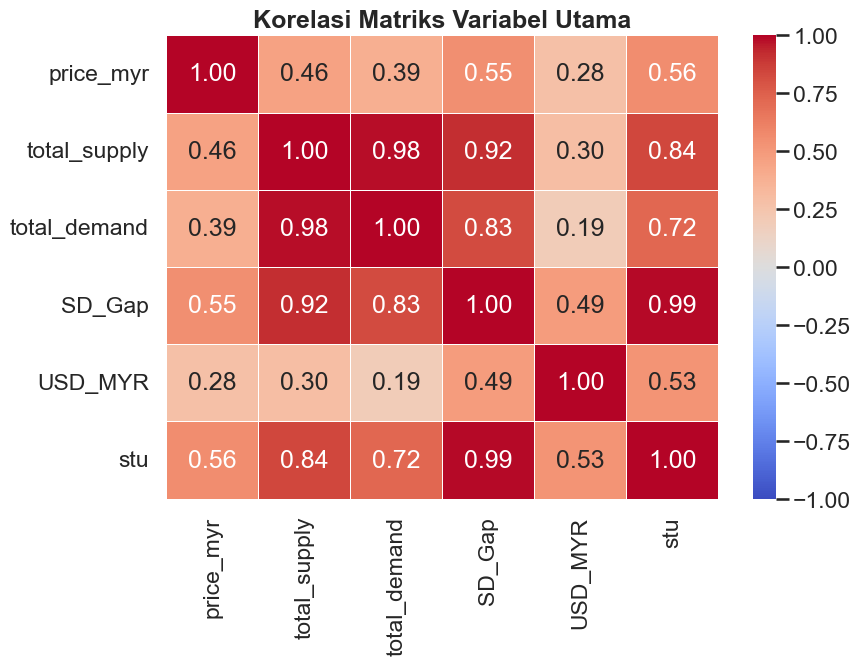

>>> Seasonal Decomposition (Log Price Bulanan)...


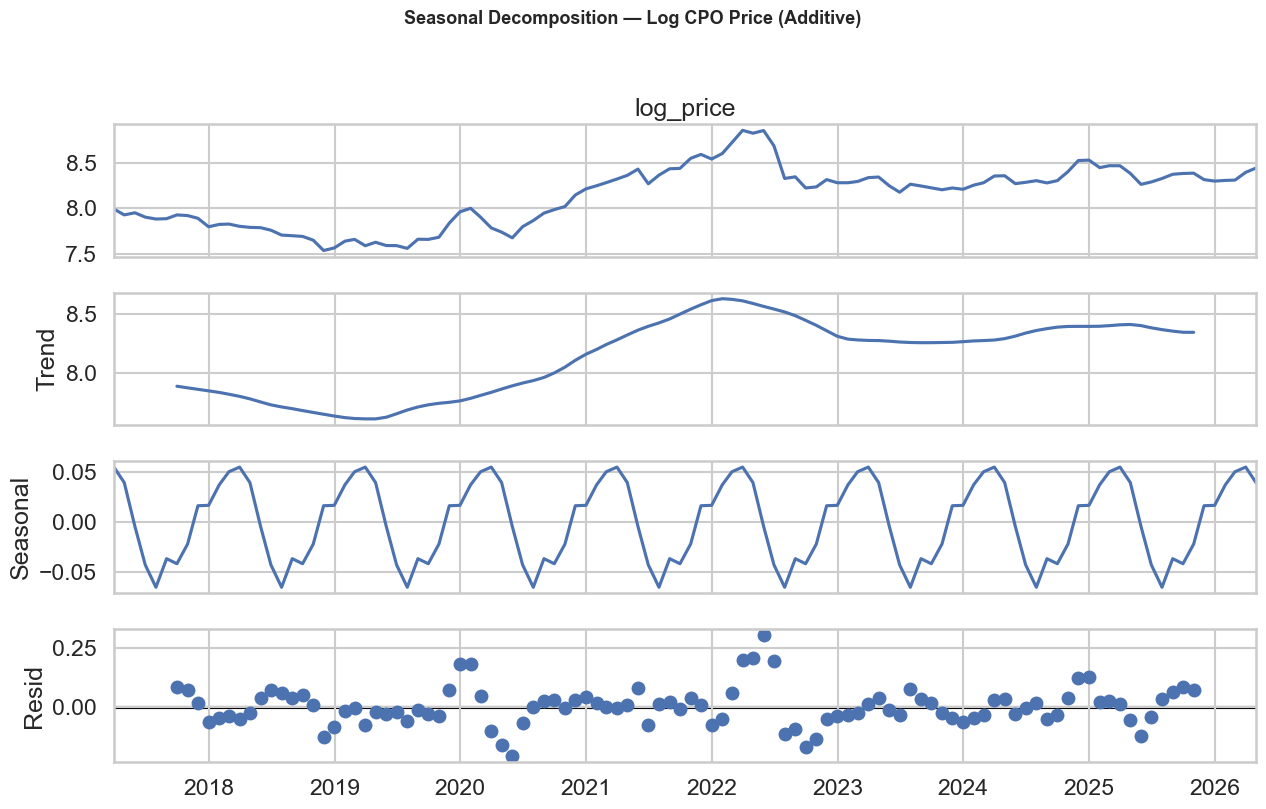


>>> Uji Stasioneritas (ADF Test):
  ADF [Daily Price MYR (level)]: p=0.3869  → ⚠️  Tidak Stasioner (butuh diff)
  ADF [Daily ΔPrice MYR (diff-1)]: p=0.0000  → ✅ Stasioner

✅ EDA Selesai.


In [2]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 3 — EXPLORATORY DATA ANALYSIS (EDA)                        ║
╚══════════════════════════════════════════════════════════════════╝
"""
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (14, 6)

print(">>> Memulai EDA (Daily Mode)...")

# ─── 1. HISTORICAL DAILY PRICE TREND ─────────────────────────────────────────
df_pd = prices_daily[PRIMARY_SYM][['price_myr']].dropna()
fig, ax = plt.subplots()
ax.plot(df_pd.index, df_pd['price_myr'], color='#D95319', lw=1.0, alpha=0.8, label='Harga CPO Harian (MYR)')
ax.plot(df_pd.index, df_pd['price_myr'].rolling(30).mean(), color='#0072BD', lw=2.0, ls='--', label='30-Day MA')
ax.set_title('Tren Historis Harga CPO Harian — Fastmarkets', fontweight='bold')
ax.set_ylabel('Harga (MYR/MT)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# ─── 2. SUPPLY vs DEMAND vs PRICE (BULANAN) ───────────────────────────────────
# Menambahkan 'stu' ke dalam join agar bisa divisualisasikan dan masuk ke Heatmap
df_mc = prices_monthly[PRIMARY_SYM][['price_myr']].join(
    supply_monthly[['total_supply', 'total_demand', 'stu']], how='inner').dropna()

fig, ax1 = plt.subplots()
ax1.plot(df_mc.index, df_mc['total_supply'], color='green', lw=2, label='Total Supply (USDA)')
ax1.plot(df_mc.index, df_mc['total_demand'], color='purple', lw=2, label='Total Demand (USDA)')
ax1.set_ylabel('Volume (1000 MT)')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(df_mc.index, df_mc['price_myr'], color='#D95319', alpha=0.5, ls=':', label='CPO Price MYR')
ax2.set_ylabel('Harga (MYR/MT)', color='#D95319')
ax2.tick_params(axis='y', labelcolor='#D95319')
ax2.legend(loc='upper right')
plt.title('Supply/Demand (USDA) vs Harga CPO (Fastmarkets)', fontweight='bold')
plt.tight_layout(); plt.show()

# ─── 2b. STOCK-TO-USE (STU) RATIO vs PRICE ────────────────────────────────────
fig, ax1 = plt.subplots()
ax1.plot(df_mc.index, df_mc['stu'], color='#7E2F8E', lw=2.5, label='Stock-to-Use (STU) Ratio %')
ax1.set_ylabel('STU Ratio (%)', color='#7E2F8E', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#7E2F8E')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(df_mc.index, df_mc['price_myr'], color='#D95319', lw=2, alpha=0.7, ls='-', label='CPO Price MYR')
ax2.set_ylabel('Harga (MYR/MT)', color='#D95319', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#D95319')
ax2.legend(loc='upper right')
plt.title('Dinamika Stock-to-Use (STU) Ratio vs Harga CPO', fontweight='bold')
plt.tight_layout(); plt.show()

# ─── 3. CORRELATION HEATMAP ───────────────────────────────────────────────────
df_corr = df_mc.copy()
df_corr['USD_MYR'] = fx_monthly['USD_MYR'].reindex(df_corr.index).ffill()
df_corr['SD_Gap']  = df_corr['total_supply'] - df_corr['total_demand']
plt.figure(figsize=(9,7))
# Kolom 'stu' sekarang aman untuk dipanggil karena sudah di-join di df_mc
corr_m = df_corr[['price_myr','total_supply','total_demand','SD_Gap','USD_MYR','stu']].corr()
sns.heatmap(corr_m, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Korelasi Matriks Variabel Utama', fontweight='bold')
plt.tight_layout(); plt.show()

# ─── 4. SEASONAL DECOMPOSITION ───────────────────────────────────────────────
print(">>> Seasonal Decomposition (Log Price Bulanan)...")
log_m = prices_monthly[PRIMARY_SYM]['log_price'].dropna()
if len(log_m) >= 24:
    decomp = seasonal_decompose(log_m, model='additive', period=12)
    fig = decomp.plot(); fig.set_size_inches(13,8)
    fig.suptitle('Seasonal Decomposition — Log CPO Price (Additive)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

# ─── 5. ADF STASIONERITAS ────────────────────────────────────────────────────
def adf_test(series, name):
    res = adfuller(series.dropna()); p = res[1]
    print(f"  ADF [{name}]: p={p:.4f}  → {'✅ Stasioner' if p<0.05 else '⚠️  Tidak Stasioner (butuh diff)'}")

print("\n>>> Uji Stasioneritas (ADF Test):")
adf_test(prices_daily[PRIMARY_SYM]['price_myr'], 'Daily Price MYR (level)')
adf_test(prices_daily[PRIMARY_SYM]['price_myr'].diff().dropna(), 'Daily ΔPrice MYR (diff-1)')

print("\n✅ EDA Selesai.")

---
## Cell 4 — Short-Term Super Hybrid Ensemble Forecast (Daily)
**Model:** VAR · SARIMAX · Random Forest · Gradient Boosting · LSTM

**Horizon:** `FORECAST_STEPS_DAILY` hari ke depan (default: 100 hari)

**Output (globals):** `ensemble_weighted`, `future_dates`, `intervention_env`

| Bobot | Model | Peran |
|---|---|---|
| 0.35 | LSTM | Memory jangka pendek harian |
| 0.25 | SARIMAX | Statistikal + eksogen supply/demand USDA |
| 0.15 | Random Forest | Non-linear pattern |
| 0.15 | Gradient Boosting | Non-linear pattern |
| 0.10 | VAR | Dinamika multivariat makro |


>>> [1/8] Menyiapkan Daily Data untuk 365 Hari Ke Depan...
    Training: 1500 hari terakhir
    Horizon : 2026-04-15 → 2027-04-14

>>> [2/8] VAR Model Training...
    -> VAR lag=14 hari.

>>> [3/8] Building ML Features (lag 1,3,7,14)...

>>> [4/8] Training RF & GB (Direct Multi-Step)...
    -> RF & GB selesai.

>>> [5/8] Training Stacked LSTM...
    -> LSTM selesai.

>>> [6/8] SARIMAX Auto-Tuning (USDA Daily Exog)...
    ✅ Best SARIMAX: (1, 1, 2)  (AIC=16132.3)

>>> [7/8] Dynamic Fisher-Weighted Ensemble...
    Dynamic Weights: LSTM=0.059 | RF=0.342 | GB=0.332 | VAR=0.265 | SARIMAX=0.002

>>> [8/8] Visualisasi Hasil...


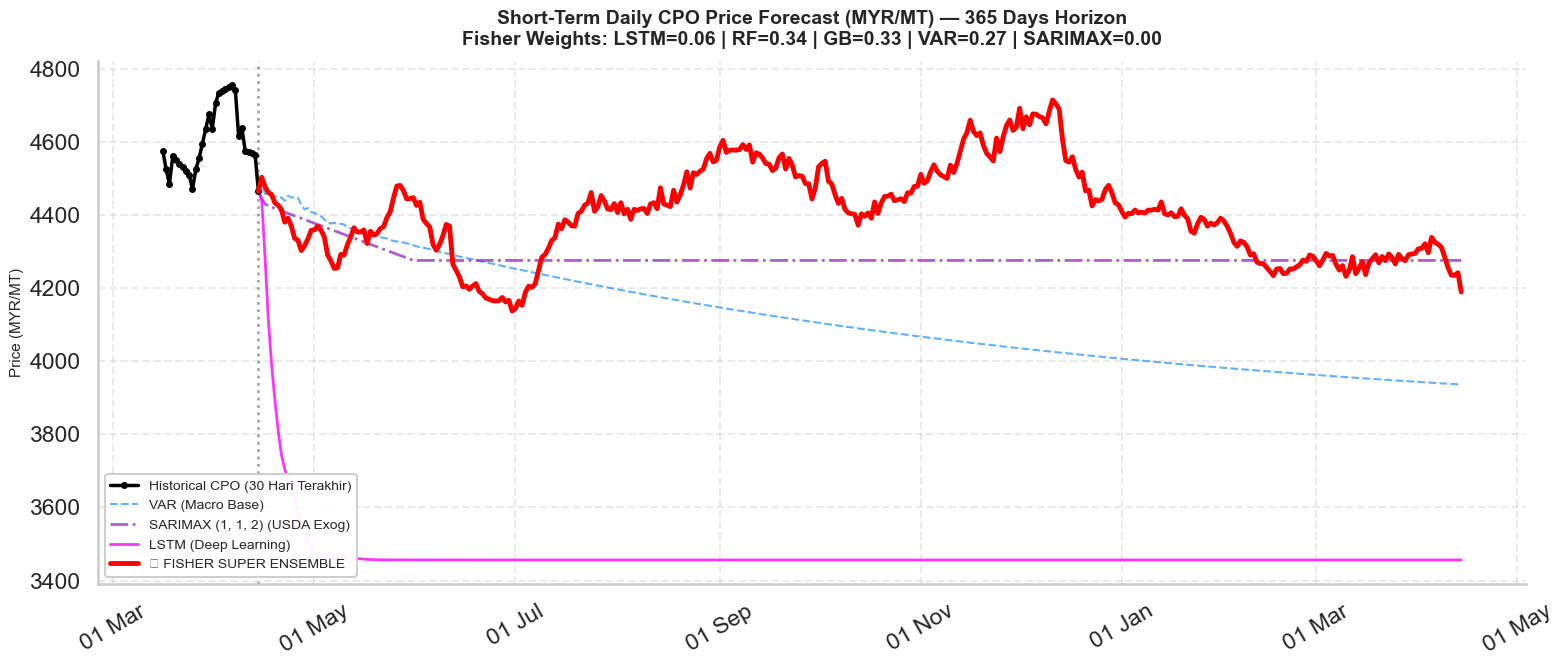


📊 Snapshot Forecast Harian (5 Hari Pertama & Terakhir):
                VAR  SARIMAX     LSTM  Ensemble
2026-04-15  4482.27  4444.55  4442.07   4503.27
2026-04-16  4457.51  4430.31  4287.36   4477.38
2026-04-17  4455.19  4425.04  4114.77   4461.81
2026-04-18  4448.31  4421.33  3990.79   4455.92
2026-04-19  4450.91  4417.89  3894.06   4433.21
2027-04-10  3938.24  4275.62  3456.22   4256.04
2027-04-11  3937.69  4275.62  3456.22   4235.18
2027-04-12  3937.15  4275.62  3456.22   4234.75
2027-04-13  3936.61  4275.62  3456.22   4241.98
2027-04-14  3936.07  4275.62  3456.22   4189.38

✅ Variabel siap: ensemble_weighted, future_dates, intervention_env


In [3]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 4 — SHORT-TERM SUPER HYBRID ENSEMBLE FORECAST (DAILY)      ║
╚══════════════════════════════════════════════════════════════════╝
"""
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings('ignore')

# ── ⚙️  KONFIGURASI ────────────────────────────────────────────────────────────
FORECAST_STEPS_DAILY = 365       # hari ke depan
RECENT_REGIME_DAYS   = 1500      # hari terakhir untuk training (~4 tahun)
TARGET_COL           = 'price_myr'

LSTM_LOOK_BACK = 20   # hari lookback LSTM
LSTM_EPOCHS    = 100
LSTM_BATCH     = 32
# ──────────────────────────────────────────────────────────────────────────────

print(f">>> [1/8] Menyiapkan Daily Data untuk {FORECAST_STEPS_DAILY} Hari Ke Depan...")

# ─── [1/8] PREPARASI DATA HARIAN ─────────────────────────────────────────────
df_daily_target = prices_daily[PRIMARY_SYM][[TARGET_COL]].copy()

# Align supply daily ke index harga (Tambahkan 'stu' di sini)
usda_aligned = supply_daily[['total_supply', 'total_demand', 'stu']].reindex(
    df_daily_target.index).interpolate(method='time').ffill().bfill()

# Sinyal teknikal harian
df_signals = pd.DataFrame(index=df_daily_target.index)
df_signals['RecentMA_14D']          = df_daily_target[TARGET_COL].rolling(14).mean()
df_signals['RecentMomentum_14D']    = df_daily_target[TARGET_COL].pct_change(14) * 100
df_signals['RecentVolatility_14D']  = df_daily_target[TARGET_COL].rolling(14).std()

# Faktor musiman harian (fundamental CPO)
df_signals['Low_Prod_Season']       = df_signals.index.month.isin([1,2,3]).astype(int)
df_signals['Peak_Prod_Season']      = df_signals.index.month.isin([8,9,10,11]).astype(int)
df_signals['Pre_Festive_Restocking']= df_signals.index.month.isin([7,8,9]).astype(int)

# Master daily — RECENT_REGIME_DAYS terakhir
df_master_daily = pd.concat([
    df_daily_target[[TARGET_COL]],
    usda_aligned,
    df_signals
], axis=1).dropna().iloc[-RECENT_REGIME_DAYS:]
ml_cols = df_master_daily.columns.tolist()

# Tanggal prediksi & eksogen masa depan (Tambahkan 'stu' di sini juga)
future_dates = pd.date_range(
    start=df_master_daily.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_STEPS_DAILY, freq='D')
exog_future_daily = supply_daily[['total_supply', 'total_demand', 'stu']].reindex(
    future_dates).ffill().bfill()

print(f"    Training: {len(df_master_daily)} hari terakhir")
print(f"    Horizon : {future_dates[0].date()} → {future_dates[-1].date()}")

# ─── [2/8] VAR MODEL ─────────────────────────────────────────────────────────
print("\n>>> [2/8] VAR Model Training...")
log_safe_cols = ['total_supply','total_demand',TARGET_COL,'RecentMA_14D','RecentVolatility_14D','stu']
momentum_cols = ['RecentMomentum_14D','Low_Prod_Season','Peak_Prod_Season','Pre_Festive_Restocking']

log_part      = np.log(df_master_daily[log_safe_cols].clip(lower=0.0001))
momentum_part = df_master_daily[momentum_cols]
combined      = pd.concat([log_part, momentum_part], axis=1)
diff_data     = combined.diff().dropna()

best_lag_var = 0
for lag in [14,7,3,1]:
    try:
        var_fitted   = VAR(diff_data).fit(lag)
        best_lag_var = var_fitted.k_ar
        break
    except Exception: continue

if best_lag_var > 0:
    forecast_diff = var_fitted.forecast(diff_data.values[-best_lag_var:], steps=FORECAST_STEPS_DAILY)
    
    # Hitung Proxy In-Sample MSE VAR
    price_col_idx = log_safe_cols.index(TARGET_COL)
    var_fitted_log_diff = var_fitted.fittedvalues.iloc[:, price_col_idx]
    actual_log_prev = np.log(df_master_daily[TARGET_COL].iloc[best_lag_var:-1].values)
    var_pred_price = np.exp(actual_log_prev + var_fitted_log_diff.values)
    actual_price = df_master_daily[TARGET_COL].iloc[best_lag_var+1:].values
    mse_var = mean_squared_error(actual_price, var_pred_price)
else:
    forecast_diff = np.tile(diff_data.mean().values, (FORECAST_STEPS_DAILY,1))
    mse_var = np.var(df_master_daily[TARGET_COL]) # Fallback jika error

last_combined = combined.iloc[-1].values
var_log_fc = np.zeros_like(forecast_diff)
var_log_fc[0] = last_combined + forecast_diff[0]
for i in range(1, FORECAST_STEPS_DAILY):
    var_log_fc[i] = var_log_fc[i-1] + forecast_diff[i]
var_forecast_prices = np.exp(var_log_fc[:, log_safe_cols.index(TARGET_COL)])
print(f"    -> VAR lag={best_lag_var} hari.")

# ─── [3/8] ML FEATURES ───────────────────────────────────────────────────────
print("\n>>> [3/8] Building ML Features (lag 1,3,7,14)...")
feature_cols = []
for col in ml_cols:
    for lag in [1,3,7,14]:
        cname = f'{col}_lag{lag}'
        df_master_daily[cname] = df_master_daily[col].shift(lag)
        feature_cols.append(cname)

# ─── [4/8] RF & GB (DIRECT MULTI-STEP) ───────────────────────────────────────
print("\n>>> [4/8] Training RF & GB (Direct Multi-Step)...")
rf_base = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)
gb_base = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)

rf_forecast_prices, gb_forecast_prices = [], []
X_pred = df_master_daily[feature_cols].iloc[-1:].ffill()

mse_rf, mse_gb = None, None

for h in range(1, FORECAST_STEPS_DAILY+1):
    tc = f'Target_D{h}'
    df_master_daily[tc] = df_master_daily[TARGET_COL].shift(-h)
    sub = df_master_daily.dropna(subset=feature_cols+[tc])
    Xt, yt = sub[feature_cols], sub[tc]
    
    rf_base.fit(Xt, yt); rf_forecast_prices.append(rf_base.predict(X_pred)[0])
    gb_base.fit(Xt, yt); gb_forecast_prices.append(gb_base.predict(X_pred)[0])
    
    # Menangkap MSE 1-hari ke depan sebagai proxy Fisher Information (Precision)
    if h == 1:
        mse_rf = mean_squared_error(yt, rf_base.predict(Xt))
        mse_gb = mean_squared_error(yt, gb_base.predict(Xt))

print("    -> RF & GB selesai.")

# ─── [5/8] LSTM ───────────────────────────────────────────────────────────────
print("\n>>> [5/8] Training Stacked LSTM...")
df_lstm     = df_master_daily[ml_cols].dropna()
scaler_lstm = MinMaxScaler()
scaled      = scaler_lstm.fit_transform(df_lstm)

X_lstm, y_lstm = [], []
for i in range(LSTM_LOOK_BACK, len(scaled)):
    X_lstm.append(scaled[i-LSTM_LOOK_BACK:i,:])
    y_lstm.append(scaled[i, ml_cols.index(TARGET_COL)])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_lstm.shape[1], X_lstm.shape[2]), recurrent_dropout=0.01),
    Dropout(0.2),
    LSTM(32, return_sequences=False, recurrent_dropout=0.01),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_lstm, y_lstm, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH, verbose=0,
               callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)])

# Evaluasi in-sample error LSTM
lstm_train_pred = lstm_model.predict(X_lstm, verbose=0)
dummy_pred = np.zeros((len(lstm_train_pred), len(ml_cols)))
dummy_pred[:, ml_cols.index(TARGET_COL)] = lstm_train_pred[:, 0]
lstm_pred_raw = scaler_lstm.inverse_transform(dummy_pred)[:, ml_cols.index(TARGET_COL)]

dummy_act = np.zeros((len(y_lstm), len(ml_cols)))
dummy_act[:, ml_cols.index(TARGET_COL)] = y_lstm
lstm_act_raw = scaler_lstm.inverse_transform(dummy_act)[:, ml_cols.index(TARGET_COL)]
mse_lstm = mean_squared_error(lstm_act_raw, lstm_pred_raw)

last_window = scaled[-LSTM_LOOK_BACK:].copy()
lstm_fc_scaled = []
for i in range(FORECAST_STEPS_DAILY):
    cur = last_window.reshape(1, LSTM_LOOK_BACK, X_lstm.shape[2])
    nxt = lstm_model.predict(cur, verbose=0)[0][0]
    lstm_fc_scaled.append(nxt)
    ns = np.zeros(X_lstm.shape[2]); ns[ml_cols.index(TARGET_COL)] = nxt
    last_window = np.vstack((last_window[1:], ns))

d_inv = np.zeros((FORECAST_STEPS_DAILY, len(ml_cols)))
d_inv[:, ml_cols.index(TARGET_COL)] = lstm_fc_scaled
lstm_forecast_prices = scaler_lstm.inverse_transform(d_inv)[:, ml_cols.index(TARGET_COL)]
print("    -> LSTM selesai.")

# ─── [6/8] SARIMAX DAILY + USDA EXOGENOUS ────────────────────────────────────
print("\n>>> [6/8] SARIMAX Auto-Tuning (USDA Daily Exog)...")
price_ts   = df_master_daily[TARGET_COL].dropna()
exog_train = df_master_daily[['total_supply','total_demand','stu']].loc[price_ts.index]

best_aic, best_order, best_sarimax_res = np.inf, None, None
for p, q in itertools.product(range(0,3), range(0,3)):
    try:
        res = SARIMAX(price_ts, exog=exog_train, order=(p,1,q),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if res.aic < best_aic:
            best_aic, best_order, best_sarimax_res = res.aic, (p,1,q), res
    except: continue

print(f"    ✅ Best SARIMAX: {best_order}  (AIC={best_aic:.1f})")

# Hitung in-sample MSE untuk SARIMAX
mse_arima = mean_squared_error(price_ts.iloc[1:], best_sarimax_res.fittedvalues.iloc[1:])

sarimax_fc            = best_sarimax_res.get_forecast(steps=FORECAST_STEPS_DAILY, exog=exog_future_daily)
arima_forecast_prices = sarimax_fc.predicted_mean.values

# ─── [7/8] FISHER-WEIGHTED ENSEMBLE (CoFIMA INSPIRED) ─────────────────────────
print("\n>>> [7/8] Dynamic Fisher-Weighted Ensemble...")
rf_arr    = np.array(rf_forecast_prices)
gb_arr    = np.array(gb_forecast_prices)
var_arr   = np.array(var_forecast_prices)
arima_arr = np.array(arima_forecast_prices)
lstm_arr  = np.array(lstm_forecast_prices)

# 1. Menghitung Inverse MSE (Precision / Fisher Information Proxy)
f_lstm  = 1.0 / (mse_lstm + 1e-8)
f_rf    = 1.0 / (mse_rf + 1e-8)
f_gb    = 1.0 / (mse_gb + 1e-8)
f_var   = 1.0 / (mse_var + 1e-8)
f_arima = 1.0 / (mse_arima + 1e-8)

total_fisher = f_lstm + f_rf + f_gb + f_var + f_arima

# 2. Menghitung bobot akhir
W_LSTM  = f_lstm / total_fisher
W_RF    = f_rf / total_fisher
W_GB    = f_gb / total_fisher
W_VAR   = f_var / total_fisher
W_ARIMA = f_arima / total_fisher

print(f"    Dynamic Weights: LSTM={W_LSTM:.3f} | RF={W_RF:.3f} | GB={W_GB:.3f} | VAR={W_VAR:.3f} | SARIMAX={W_ARIMA:.3f}")

ensemble_weighted = (
    W_LSTM  * lstm_arr  +
    W_ARIMA * arima_arr +
    W_RF    * rf_arr    +
    W_GB    * gb_arr    +
    W_VAR   * var_arr
)

# ─── [8/8] VISUALISASI ───────────────────────────────────────────────────────
print("\n>>> [8/8] Visualisasi Hasil...")
fig, ax = plt.subplots(figsize=(16,7))
last_date  = df_master_daily.index[-1]
last_price = df_master_daily[TARGET_COL].iloc[-1]
plot_dates = [last_date] + list(future_dates)

ax.plot(df_master_daily.index[-30:], df_master_daily[TARGET_COL].iloc[-30:],
        color='black', lw=2.5, marker='o', ms=4, label='Historical CPO (30 Hari Terakhir)', zorder=5)
ax.plot(plot_dates, [last_price]+list(var_arr),
        color='dodgerblue', ls='--', lw=1.5, alpha=0.7, label='VAR (Macro Base)')
ax.plot(plot_dates, [last_price]+list(arima_arr),
        color='darkorchid', ls='-.', lw=2.0, alpha=0.8, label=f'SARIMAX {best_order} (USDA Exog)')
ax.plot(plot_dates, [last_price]+list(lstm_arr),
        color='magenta', lw=2.0, alpha=0.8, label='LSTM (Deep Learning)')
ax.plot(plot_dates, [last_price]+list(ensemble_weighted),
        color='red', lw=3.5, zorder=10, label='🔥 FISHER SUPER ENSEMBLE')

ax.axvline(x=last_date, color='grey', ls=':', lw=2, alpha=0.7)
ax.set_title(
    f'Short-Term Daily CPO Price Forecast (MYR/MT) — {FORECAST_STEPS_DAILY} Days Horizon\n'
    f'Fisher Weights: LSTM={W_LSTM:.2f} | RF={W_RF:.2f} | GB={W_GB:.2f} | VAR={W_VAR:.2f} | SARIMAX={W_ARIMA:.2f}',
    fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Price (MYR/MT)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
ax.grid(True, ls='--', alpha=0.4)
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# Snapshot tabel
df_fr = pd.DataFrame({
    'VAR': var_arr, 'SARIMAX': arima_arr, 'LSTM': lstm_arr, 'Ensemble': ensemble_weighted
}, index=future_dates).round(2)
print("\n📊 Snapshot Forecast Harian (5 Hari Pertama & Terakhir):")
print(pd.concat([df_fr.head(), df_fr.tail()]))

# Bungkus intervention environment (NAMA VARIABEL TETAP DIPERTAHANKAN)
try:
    last_actual_price_val = last_actual_price
except NameError:
    last_actual_price_val = last_price

try:
    latest_kurs_val = latest_kurs
except NameError:
    latest_kurs_val = 1.0 # Fallback jika tidak terdefinisi di cell ini

intervention_env = {
    'df_master_daily'  : df_master_daily.copy(),
    'future_dates'     : future_dates,
    'target_col'       : TARGET_COL,
    'exog_future_base' : exog_future_daily.copy(),
    'best_sarimax_res' : best_sarimax_res,
    'best_order'       : best_order,
    'var_fitted'       : var_fitted,
    'best_lag_var'     : best_lag_var,
    'combined'         : combined,
    'log_safe_cols'    : log_safe_cols,
    # Bobot Dinamis yang baru di-update: (LSTM, RF, GB, VAR, SARIMAX)
    'weights'          : (W_LSTM, W_RF, W_GB, W_VAR, W_ARIMA),
    'p_base_sim'       : ensemble_weighted,
    'arima_base'       : arima_arr,
    'var_base'         : var_arr,
    'lstm_base'        : lstm_arr,
    'rf_base'          : rf_arr,
    'gb_base'          : gb_arr,
    'last_actual_price': last_actual_price_val,
    'latest_kurs'      : latest_kurs_val,
}
print(f"\n✅ Variabel siap: ensemble_weighted, future_dates, intervention_env")

---
## Cell 5 — Intervention Analysis (Rational Transfer Function — Daily)
**Input:** `intervention_env` (dari Cell 4)

**Output:** `p_base_myr`, `p_interv_myr`, `df_eval`

---

### 📐 Panduan ω (Omega) & δ (Delta) — Satuan HARI

| Parameter | Deskripsi |
|---|---|
| **ω** | Besaran dampak awal shock terhadap supply/demand (%) |
| **δ** | Decay rate **per hari** (0 < δ < 1) |

| δ | Half-life | Hilang 95% | Karakteristik |
|---|---|---|---|
| 0.40 | 0.9 hari | ~4 hari | Ultra-cepat |
| 0.70 | 1.9 hari | ~8 hari | Sentimen harian |
| 0.85 | 4.3 hari | ~18 hari | Berita pekan |
| 0.93 | 9.5 hari | ~41 hari | Berita bulanan awal |
| 0.97 | 22.8 hari | ~97 hari | Kebijakan jangka menengah |
| 0.99 | 68.9 hari | ~298 hari | Perubahan struktural |

> **Aturan Praktis:**
> - Pulse (berita harian): δ = 0.70–0.85
> - Step (kebijakan): δ = 0.90–0.97
> - Perubahan permanen: δ = 0.97–0.99


 Horizon   : 365 hari (2026-04-15 → 2027-04-14)
 Kurs ref  : USD/MYR = 3.9569
 Baseline  : RM 4,503 → RM 4,189 MYR/MT

 ✓ Policy: B40/B50 Biodiesel Mandate
   Tipe: STEP | Harga: +180 MYR/MT | Exog: +6.0% (total_demand)
   Mulai: 2026-04-20 | δ=0.985 | t½=45.9d | t₉₅=198.2d

 ✓ Geopolitics: Supply Chain Disruption
   Tipe: PULSE | Harga: +120 MYR/MT | Exog: -4.0% (total_supply)
   Mulai: 2026-04-25 | δ=0.88 | t½=5.4d | t₉₅=23.4d

 ✓ Relief: MPOB High Inventory Report
   Tipe: PULSE | Harga: -55 MYR/MT | Exog: +8.0% (total_supply)
   Mulai: 2026-05-05 | δ=0.82 | t½=3.5d | t₉₅=15.1d

 ✓ Structural: Reduced War Tensions
   Tipe: STEP | Harga: -90 MYR/MT | Exog: -3.0% (total_demand)
   Mulai: 2026-05-15 | δ=0.96 | t½=17.0d | t₉₅=73.4d



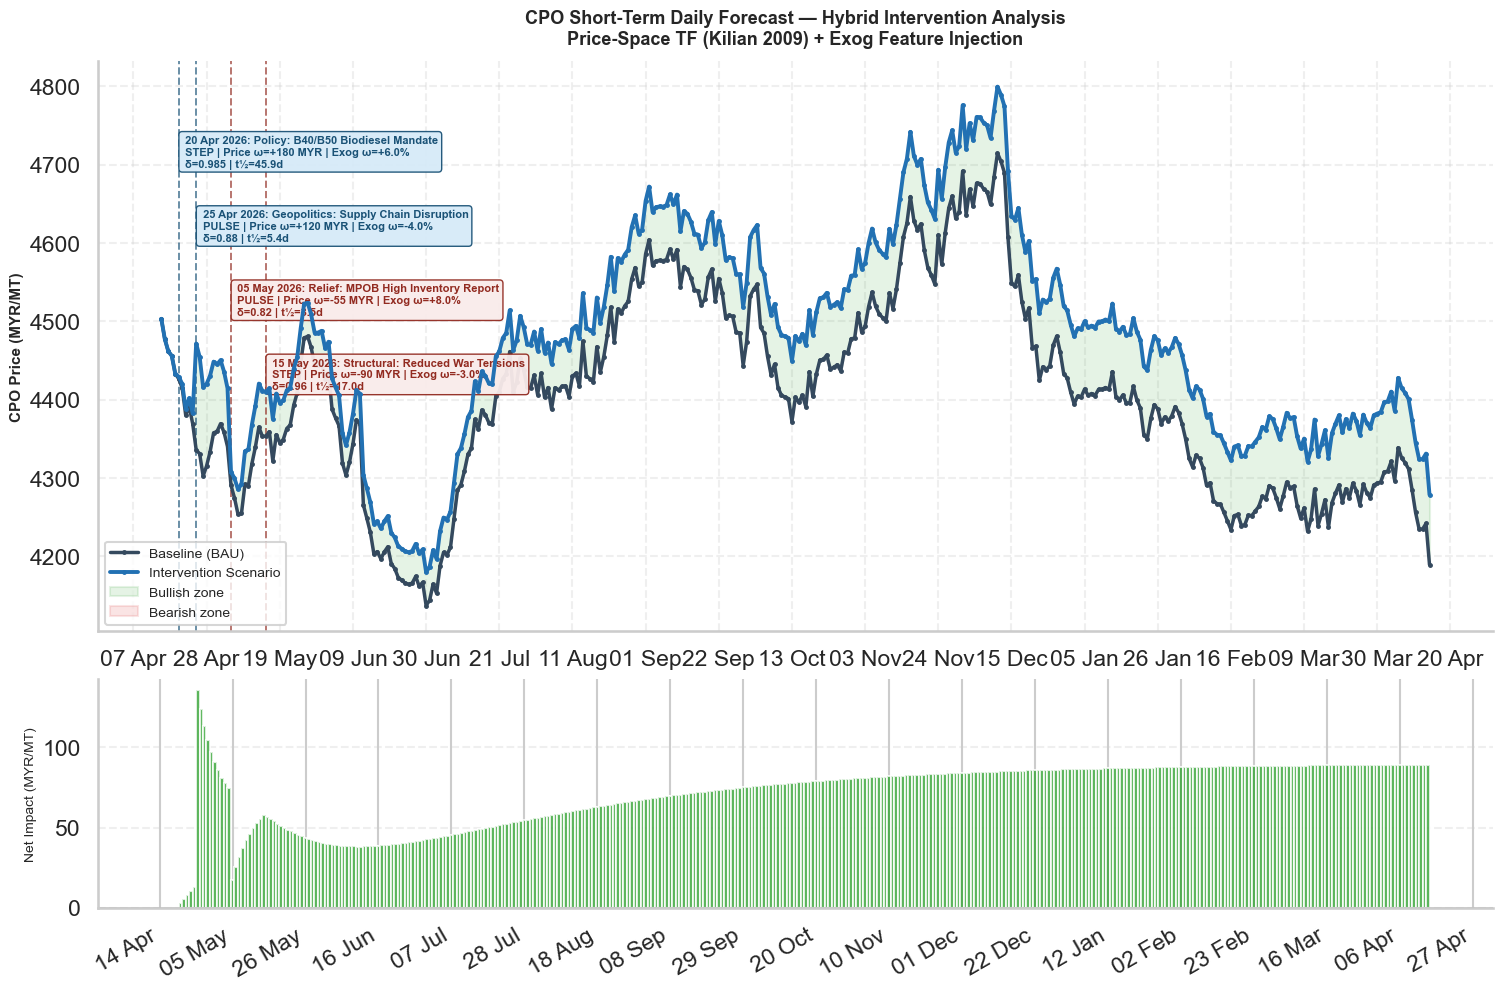


──────────────────────────────────────────────────────────────────────────────────────────
 Tanggal           Baseline        Interv     vs Base       DoD
──────────────────────────────────────────────────────────────────────────────────────────
 15 Apr 2026   RM     4,503  RM     4,503         +0      +38
 16 Apr 2026   RM     4,477  RM     4,477         +0      -26
 17 Apr 2026   RM     4,462  RM     4,462         +0      -16
 18 Apr 2026   RM     4,456  RM     4,456         +0       -6
 19 Apr 2026   RM     4,433  RM     4,433         +0      -23
 20 Apr 2026   RM     4,427  RM     4,429         +3       -4
 21 Apr 2026   RM     4,415  RM     4,420         +5       -9
 22 Apr 2026   RM     4,380  RM     4,388         +8      -32
 23 Apr 2026   RM     4,391  RM     4,402        +11      +14
 24 Apr 2026   RM     4,369  RM     4,382        +13      -19
          ...
 10 Apr 2027   RM     4,256  RM     4,345        +89      -29
 11 Apr 2027   RM     4,235  RM     4,324        +89     

In [4]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 5 — INTERVENTION ANALYSIS (HYBRID RATIONAL TF)             ║
║  Satuan waktu: HARI                                              ║
║                                                                  ║
║  METODE: Direct Price-Space TF (Box-Tiao 1975) untuk Harga       ║
║        + Exog Feature Injection untuk Downstream Consistency     ║
║                                                                  ║
║  Kalibrasi referensi:                                            ║
║    Kilian (2009, AER)          — commodity price elasticity      ║
║    Baumeister & Peersman (2013)— daily decay rates               ║
║    Jordà (2005, AER)           — local projection IRF validation ║
╚══════════════════════════════════════════════════════════════════╝

PERBAIKAN ARSITEKTUR HYBRID:
─────────────────────────────────────────────────────────────────────
  ✅ Harga diproyeksikan menggunakan Direct Price-Space TF (MYR/MT) 
     untuk mencegah amplifikasi non-linear dari koefisien SARIMAX.
  ✅ Nilai exog (total_supply / total_demand) tetap diinjeksi 
     dengan persentase shock (omega_pct) seperti pada versi lama, 
     sehingga dataframe `exog_interv` siap digunakan untuk pipeline 
     model lain di luar SARIMAX.
─────────────────────────────────────────────────────────────────────
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── ⚙️  KONFIGURASI SKENARIO — UBAH DI SINI ─────────────────────────────────
#
# omega_myr : dampak harga PUNCAK dalam MYR/MT (untuk kalkulasi harga)
# omega_pct : % dampak shock pada target_feature (untuk update exog_interv)
# target_feature : kolom eksogen yang akan diinjeksi (total_supply/total_demand)
# delta     : decay rate per HARI

CUSTOM_INTERVENTIONS = [
    {
        'date'          : pd.Timestamp('2026-04-20'),
        'event_name'    : 'Policy: B40/B50 Biodiesel Mandate',
        'target_feature': 'total_demand',
        'type'          : 'step',
        'omega_myr'     : +180.0,  # Dampak langsung ke MYR/MT
        'omega_pct'     : +6.0,    # Demand naik 6%
        'delta'         : 0.985,   # half-life 46 hari
    },
    {
        'date'          : pd.Timestamp('2026-04-25'),
        'event_name'    : 'Geopolitics: Supply Chain Disruption',
        'target_feature': 'total_supply',
        'type'          : 'pulse',
        'omega_myr'     : +120.0,  # Supply drop (Bullish ke harga)
        'omega_pct'     : -4.0,    # Supply drop 4%
        'delta'         : 0.880,   # half-life 5.4 hari
    },
    {
        'date'          : pd.Timestamp('2026-05-05'),
        'event_name'    : 'Relief: MPOB High Inventory Report',
        'target_feature': 'total_supply',
        'type'          : 'pulse',
        'omega_myr'     : -55.0,   # Koreksi sentimen (Bearish)
        'omega_pct'     : +8.0,    # Laporan supply naik 8%
        'delta'         : 0.820,   # half-life 3.5 hari
    },
    {
        'date'          : pd.Timestamp('2026-05-15'),
        'event_name'    : 'Structural: Reduced War Tensions',
        'target_feature': 'total_demand',
        'type'          : 'step',
        'omega_myr'     : -90.0,   # Normalisasi (Bearish)
        'omega_pct'     : -3.0,    # Pasokan/Demand kembali pulih 3%
        'delta'         : 0.960,   # half-life 17 hari
    },
]

MAX_PRICE_MYR = 7500.0   # hard cap
MIN_PRICE_MYR = 2000.0   # hard floor 

# ──────────────────────────────────────────────────────────────────────────────

# ─── HELPER: KALKULASI HALF-LIFE & t95 ────────────────────────────────────────
def tf_metrics(delta):
    if delta <= 0 or delta >= 1: return np.nan, np.nan
    return np.log(0.5) / np.log(delta), np.log(0.05) / np.log(delta)

# ─── TRANSFER FUNCTION BUILDER ────────────────────────────────────────────────
def build_tf(omega, delta, shock_type, n_steps):
    """
    Berfungsi ganda: bisa menghasilkan vektor MYR/MT (jika omega = omega_myr)
    atau vektor persentase (jika omega = omega_pct_harian).
    """
    effect = np.zeros(n_steps)
    if shock_type == 'pulse':
        for t in range(n_steps):
            effect[t] = omega * (delta ** t)
    elif shock_type == 'step':
        effect[0] = omega * (1 - delta)
        for t in range(1, n_steps):
            effect[t] = delta * effect[t - 1] + omega * (1 - delta)
    return effect

# ─── AMBIL VARIABEL DARI CELL SEBELUMNYA ──────────────────────────────────────
f_dates     = intervention_env['future_dates']
steps_count = len(f_dates)
kurs        = intervention_env['latest_kurs']
p_base_myr  = np.array(intervention_env['p_base_sim'])

# Siapkan dataframe exog baru untuk tracking
try:
    exog_interv = intervention_env['exog_future_base'].copy()
except KeyError:
    print("⚠ exog_future_base tidak ditemukan. Pastikan sudah ada di intervention_env.")
    exog_interv = None

print(f" Horizon   : {steps_count} hari ({f_dates[0].date()} → {f_dates[-1].date()})")
print(f" Kurs ref  : USD/MYR = {kurs:.4f}")
print(f" Baseline  : RM {p_base_myr[0]:,.0f} → RM {p_base_myr[-1]:,.0f} MYR/MT\n")


# ─── AKUMULASI DAMPAK HARGA & INJEKSI EXOG ────────────────────────────────────
cumulative_impact = np.zeros(steps_count)

for interv in CUSTOM_INTERVENTIONS:
    start_date = interv['date']

    if start_date not in f_dates:
        print(f" ⚠ Skip '{interv['event_name']}': {start_date.date()} di luar horizon.")
        continue

    start_idx = f_dates.get_loc(start_date)
    n_remaining = steps_count - start_idx

    # 1. Bangun IRF untuk HARGA (Direct Price-Space)
    price_effect = build_tf(
        omega      = interv['omega_myr'],
        delta      = interv['delta'],
        shock_type = interv['type'],
        n_steps    = n_remaining
    )
    cumulative_impact[start_idx:] += price_effect

    # 2. Bangun IRF untuk TARGET FEATURE (Injeksi Exog)
    if exog_interv is not None and 'target_feature' in interv:
        col = interv['target_feature']
        time_scaler = 30.0 
        omega_exog_daily = interv['omega_pct'] / time_scaler
        
        exog_effect = build_tf(
            omega      = omega_exog_daily,
            delta      = interv['delta'],
            shock_type = interv['type'],
            n_steps    = n_remaining
        )
        
        # Apply efek ke target feature
        for t in range(n_remaining):
            exog_interv.at[f_dates[start_idx+t], col] *= (1 + exog_effect[t] / 100.0)

    # Log
    t_half, t_95 = tf_metrics(interv['delta'])
    print(f" ✓ {interv['event_name']}")
    print(f"   Tipe: {interv['type'].upper()} | Harga: {interv['omega_myr']:+.0f} MYR/MT | Exog: {interv['omega_pct']:+.1f}% ({interv.get('target_feature','')})")
    print(f"   Mulai: {start_date.date()} | δ={interv['delta']} | t½={t_half:.1f}d | t₉₅={t_95:.1f}d\n")

# ─── HITUNG HARGA FINAL p_interv_myr ──────────────────────────────────────────
p_interv_myr = np.clip(
    p_base_myr + cumulative_impact,
    a_min=MIN_PRICE_MYR,
    a_max=MAX_PRICE_MYR
)
net_impact = p_interv_myr - p_base_myr


# ─── EVALUATION TABLE ─────────────────────────────────────────────────────────
evaluation_results = []
for interv in CUSTOM_INTERVENTIONS:
    start_d = interv['date']
    if start_d not in f_dates: continue
    si      = f_dates.get_loc(start_d)
    diff    = net_impact[si:]
    peak_v  = diff[np.argmax(np.abs(diff))] if len(diff) > 0 else 0.0
    t_half, t_95 = tf_metrics(interv['delta'])
    evaluation_results.append({
        'event'              : interv['event_name'],
        'type'               : interv['type'],
        'omega_myr'          : interv['omega_myr'],
        'target_feature'     : interv.get('target_feature', '-'),
        'exog_omega_pct'     : interv.get('omega_pct', 0),
        'delta'              : interv['delta'],
        'peak_impact_myr'    : round(peak_v, 1),
        't_half_days'        : round(t_half, 1),
    })

df_eval = pd.DataFrame(evaluation_results)


# ─── VISUALISASI ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], hspace=0.12)
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

ax1.plot(f_dates, p_base_myr,   color='#34495e', lw=2.5, marker='o', ms=2.5, label='Baseline (BAU)', zorder=3)
ax1.plot(f_dates, p_interv_myr, color='#2271b3', lw=2.8, marker='o', ms=2.5, label='Intervention Scenario', zorder=4)

ax1.fill_between(f_dates, p_base_myr, p_interv_myr, where=(p_interv_myr >= p_base_myr), color='#2ca02c', alpha=0.12, label='Bullish zone')
ax1.fill_between(f_dates, p_base_myr, p_interv_myr, where=(p_interv_myr <  p_base_myr), color='#d62728', alpha=0.12, label='Bearish zone')

ylo, yhi = ax1.get_ylim()
y_range  = yhi - ylo
for i, interv in enumerate(CUSTOM_INTERVENTIONS):
    start_d = interv['date']
    if start_d not in f_dates: continue
    t_half_d, _ = tf_metrics(interv['delta'])
    clr  = '#1a5276' if interv['omega_myr'] >= 0 else '#922b21'
    lclr = '#d6eaf8' if interv['omega_myr'] >= 0 else '#f9ebea'
    ax1.axvline(start_d, color=clr, lw=1.4, ls='--', alpha=0.65)
    y_pos = yhi - y_range * 0.13 * (i % 4 + 1)
    ax1.text(
        start_d + pd.Timedelta(days=1), y_pos,
        f" {start_d.strftime('%d %b %Y')}: {interv['event_name']}\n"
        f" {interv['type'].upper()} | Price ω={interv['omega_myr']:+.0f} MYR | Exog ω={interv.get('omega_pct',0):+.1f}%\n"
        f" δ={interv['delta']} | t½={t_half_d:.1f}d",
        fontsize=8, color=clr, fontweight='bold', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc=lclr, ec=clr, lw=1, alpha=0.95)
    )

ax1.set_title(
    'CPO Short-Term Daily Forecast — Hybrid Intervention Analysis\n'
    'Price-Space TF (Kilian 2009) + Exog Feature Injection',
    fontsize=13, fontweight='bold', pad=12
)
ax1.set_ylabel('CPO Price (MYR/MT)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, ls='--', alpha=0.3)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

colors_bar = ['#2ca02c' if v >= 0 else '#d62728' for v in net_impact]
ax2.bar(f_dates, net_impact, color=colors_bar, width=1.0, alpha=0.8)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Net Impact (MYR/MT)', fontsize=10)
ax2.grid(True, ls='--', alpha=0.3, axis='y')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ─── OUTPUT TABLE ─────────────────────────────────────────────────────────────
# Menggunakan numpy pad untuk menghindari error jika last_actual_price tidak ada
try:
    dod_start = intervention_env['last_actual_price']
except KeyError:
    dod_start = p_interv_myr[0]
diff_dod = np.diff(p_interv_myr, prepend=dod_start)

print(f"\n{'─'*90}")
print(f" {'Tanggal':<12}  {'Baseline':>12}  {'Interv':>12}  {'vs Base':>10}  {'DoD':>8}")
print(f"{'─'*90}")
for i, dt in enumerate(f_dates):
    if i < 10 or i >= steps_count - 5:
        print(f" {dt.strftime('%d %b %Y'):<12}  "
              f"RM {p_base_myr[i]:>9,.0f}  "
              f"RM {p_interv_myr[i]:>9,.0f}  "
              f"{net_impact[i]:>+9,.0f}  "
              f"{diff_dod[i]:>+7,.0f}")
    elif i == 10:
        print(f" {'  ...':>12}")
print(f"{'─'*90}")

peak_idx = np.argmax(np.abs(net_impact))
print(f"\n Avg Impact  : {net_impact.mean():+.1f} MYR/MT")
print(f" Peak Impact : {net_impact[peak_idx]:+.0f} MYR/MT ({f_dates[peak_idx].strftime('%d %b %Y')})")
print(f"\n Evaluation Table (Hybrid):")
print(df_eval.to_string(index=False))
print("\n✅ Variabel siap: p_base_myr, p_interv_myr, net_impact, df_eval, exog_interv")

---
## Cell 6 — Omega–Delta Calibration (Isolated, Daily)
**Input:** `CUSTOM_INTERVENTIONS`, `intervention_env`, `p_base_myr`

**Output:** `df_eval_isolated` — evaluasi terisolasi per event dalam satuan **HARI**


In [5]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 6 — OMEGA–DELTA CALIBRATION (ISOLATED, DAILY)            ║
║  t_half dan t_95 dalam satuan HARI (bukan bulan)               ║
╚══════════════════════════════════════════════════════════════════╝
"""
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("=" * 85)
print(" 🧠 OMEGA–DELTA IMPACT CALIBRATION (ISOLATED, SATUAN HARI)")
print("=" * 85)

f_dates     = intervention_env['future_dates']
steps_count = len(f_dates)
p_base_arr  = np.array(p_base_myr)

def t_metrics_days(delta):
    if delta <= 0 or delta >= 1: return np.nan, np.nan
    return np.log(0.5)/np.log(delta), np.log(0.05)/np.log(delta)

evaluation_results = []

for interv in CUSTOM_INTERVENTIONS:
    start_d = interv['date']
    if start_d not in f_dates: continue
    start_idx = f_dates.get_loc(start_d)
    omega, delta, v_type, col = interv['omega_myr'], interv['delta'], interv['type'], interv['target_feature']
    n = steps_count - start_idx

    # Isolated exog (hanya event ini saja)
    exog_temp = intervention_env['exog_future_base'].copy()
    tf = np.zeros(n)
    if v_type == 'pulse':
        for t in range(n): tf[t] = omega * (delta ** t)
    elif v_type == 'step':
        tf[0] = omega * (1 - delta)
        for t in range(1, n): tf[t] = delta * tf[t-1] + omega * (1 - delta)
    for t in range(n):
        exog_temp.at[f_dates[start_idx+t], col] *= (1 + tf[t] / 100.0)

    # Re-forecast SARIMAX isolated
    try:
        arima_iso = intervention_env['best_sarimax_res'].get_forecast(
            steps=steps_count, exog=exog_temp).predicted_mean.values
    except Exception:
        arima_iso = intervention_env['arima_base']

    W_LSTM, W_RF, W_GB, W_VAR, W_SARIMAX = intervention_env['weights']
    impact_delta = arima_iso - intervention_env['arima_base']
    p_temp = p_base_arr + (W_SARIMAX * impact_delta)
    diff   = p_temp - p_base_arr
    impact_series = pd.Series(diff, index=f_dates).iloc[start_idx:]

    if v_type == 'pulse':
        peak_v, peak_day = impact_series.iloc[0], 0
    else:
        peak_v, peak_day = impact_series.iloc[-1], len(impact_series)-1

    t_half, t_95 = t_metrics_days(delta)
    evaluation_results.append({
        'event'              : interv['event_name'],
        'type'               : v_type,
        'target'             : col,
        'omega (%)'          : omega,
        'delta (per day)'    : delta,
        'peak_impact_myr'    : peak_v,
        'MYR_per_1pct_omega' : abs(peak_v)/abs(omega) if omega != 0 else np.nan,
        't_half_DAYS'        : t_half,
        't_95_DAYS'          : t_95,
        'time_to_peak_days'  : peak_day,
    })

df_eval_isolated = pd.DataFrame(evaluation_results)

print("\n" + "="*85)
print(" ISOLATED EVALUATION TABLE (Daily Scale)")
print("="*85)
print(df_eval_isolated.round(2).to_string())

print("\n" + "="*85)
print(" 📊 INTERPRETASI PER EVENT")
print("="*85)

for _, row in df_eval_isolated.iterrows():
    t_h, t_95 = row['t_half_DAYS'], row['t_95_DAYS']
    char = ("Ultra-cepat (<3 hari)" if t_h < 3 else
            "Cepat (3–10 hari)"     if t_h < 10 else
            "Menengah (10–30 hari)" if t_h < 30 else
            "Lambat (>30 hari)")
    if row['type'] == 'pulse':
        print(f"""
⚡ {row['event']}
   Tipe              : Pulse (Daily Temporary Shock)
   ω={row['omega (%)']:+.1f}%  δ={row['delta (per day)']} per hari
   Dampak hari ke-1  : {row['peak_impact_myr']:+.2f} MYR/MT  (puncak langsung)
   Sensitivitas      : 1% shock ≈ {row['MYR_per_1pct_omega']:.2f} MYR/MT
   Half-life         : {t_h:.1f} HARI
   Hilang (~95%)     : {t_95:.1f} HARI
   Karakteristik     : {char}""")
    else:
        horizon = steps_count
        print(f"""
📈 {row['event']}
   Tipe                   : Step (Structural Daily Change)
   ω={row['omega (%)']:+.1f}%  δ={row['delta (per day)']} per hari
   Dampak jangka panjang  : {row['peak_impact_myr']:+.2f} MYR/MT
   Sensitivitas           : 1% shock ≈ {row['MYR_per_1pct_omega']:.2f} MYR/MT
   50% efek tercapai      : {t_h:.1f} HARI
   Full effect (~95%)     : {t_95:.1f} HARI
   Dalam {horizon} hari horizon  : {'✅ Fully realized' if t_95 <= horizon else '⚠️  Belum fully realized (persisten)'}""")

print("\n" + "="*85)
print(" ✅ Calibration selesai — ω & δ interpretable dalam MYR & HARI")
print("="*85)


 🧠 OMEGA–DELTA IMPACT CALIBRATION (ISOLATED, SATUAN HARI)

 ISOLATED EVALUATION TABLE (Daily Scale)
                                  event   type        target  omega (%)  delta (per day)  peak_impact_myr  MYR_per_1pct_omega  t_half_DAYS  t_95_DAYS  time_to_peak_days
0     Policy: B40/B50 Biodiesel Mandate   step  total_demand      180.0             0.98         -5987.49               33.26        45.86     198.21                359
1  Geopolitics: Supply Chain Disruption  pulse  total_supply      120.0             0.88          3904.89               32.54         5.42      23.43                  0
2    Relief: MPOB High Inventory Report  pulse  total_supply      -55.0             0.82         -1790.99               32.56         3.49      15.10                  0
3      Structural: Reduced War Tensions   step  total_demand      -90.0             0.96          3006.78               33.41        16.98      73.39                334

 📊 INTERPRETASI PER EVENT

📈 Policy: B40/B50 Biodiesel

---
## Cell 7 — Export Output (JSON + CSV)
**Input:** `p_base_myr`, `p_interv_myr`, `future_dates`

**Output:** `cpo_shortterm_forecast.json` dan `cpo_shortterm_forecast.csv`


In [6]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  CELL 7 — EXPORT OUTPUT (JSON + CSV)                            ║
╚══════════════════════════════════════════════════════════════════╝
"""
import pandas as pd
import numpy as np

# ── ⚙️  KONFIGURASI ────────────────────────────────────────────────────────────
JSON_OUTPUT = "cpo_shortterm_forecast.json"
CSV_OUTPUT  = "cpo_shortterm_forecast.csv"
# ──────────────────────────────────────────────────────────────────────────────

export_df = pd.DataFrame({
    'date'         : pd.to_datetime(future_dates).strftime('%Y-%m-%d'),
    'baseline_myr' : p_base_myr.round(2),
    'interv_myr'   : p_interv_myr.round(2),
    'net_impact'   : (p_interv_myr - p_base_myr).round(2),
})

# JSON (untuk visualisasi HTML/dashboard)
export_df.to_json(JSON_OUTPUT, orient='records', indent=2)

# CSV (untuk Excel / laporan)
export_df.to_csv(CSV_OUTPUT, index=False)

print(f"✅ JSON : {JSON_OUTPUT}  ({len(export_df)} baris)")
print(f"✅ CSV  : {CSV_OUTPUT}  ({len(export_df)} baris)")
print()
print(export_df.head(10).to_string(index=False))
print("...")
print(export_df.tail(5).to_string(index=False))

print(f"\n  Avg Baseline   : RM {export_df['baseline_myr'].mean():,.0f}/MT")
print(f"  Avg Interv     : RM {export_df['interv_myr'].mean():,.0f}/MT")
print(f"  Avg Net Impact : {export_df['net_impact'].mean():+,.1f} MYR/MT")
peak_idx = export_df['net_impact'].abs().idxmax()
print(f"  Peak Impact    : {export_df.loc[peak_idx,'net_impact']:+,.0f} MYR/MT"
      f" ({export_df.loc[peak_idx,'date']})")


✅ JSON : cpo_shortterm_forecast.json  (365 baris)
✅ CSV  : cpo_shortterm_forecast.csv  (365 baris)

      date  baseline_myr  interv_myr  net_impact
2026-04-15       4503.27     4503.27        0.00
2026-04-16       4477.38     4477.38        0.00
2026-04-17       4461.81     4461.81        0.00
2026-04-18       4455.92     4455.92        0.00
2026-04-19       4433.21     4433.21        0.00
2026-04-20       4426.65     4429.35        2.70
2026-04-21       4414.85     4420.21        5.36
2026-04-22       4380.22     4388.20        7.98
2026-04-23       4391.16     4401.72       10.56
2026-04-24       4369.39     4382.49       13.10
...
      date  baseline_myr  interv_myr  net_impact
2027-04-10       4256.04     4345.21       89.17
2027-04-11       4235.18     4324.36       89.18
2027-04-12       4234.75     4323.94       89.20
2027-04-13       4241.98     4331.19       89.21
2027-04-14       4189.38     4278.60       89.22

  Avg Baseline   : RM 4,404/MT
  Avg Interv     : RM 4,474/MT
